# RFP 요구사항 데이터셋 v0.2.0 EDA 노트북

이 노트북은 `data/processed/requirements_v0.2.0.jsonl` (총 1,024행) 동결 데이터셋의 문서별/유형별 분포, 본문 길이, 중첩표 및 승인된 원문 예외 ID를 탐색하고 시각화합니다.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 한글 폰트 설정 (Windows/Linux/Mac 공통 지원 시도)
plt.rcParams['font.family'] = 'Malgun Gothic' if os.name == 'nt' else 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

dataset_path = Path('../data/processed/requirements_v0.2.0.jsonl')
if not dataset_path.exists():
    dataset_path = Path('data/processed/requirements_v0.2.0.jsonl')

df = pd.read_json(dataset_path, lines=True)

def normalize_req_type(raw_type):
    if not raw_type or raw_type == 'None' or str(raw_type) == 'nan':
        return '미지정 (None)'
    t = str(raw_type).strip()
    if any(k in t for k in ['기능', 'SFR', 'AI 활용 업무', 'AI 기반 솔루션', '그룹웨어', '서비스']):
        return '기능 요구사항'
    if '성능' in t or 'PER' in t:
        return '성능 요구사항'
    if '보안' in t or 'SER' in t:
        return '보안 요구사항'
    if '데이터' in t or 'DAR' in t or 'ECM' in t:
        return '데이터 요구사항'
    if '품질' in t or 'QUR' in t:
        return '품질 요구사항'
    if '인터페이스' in t or 'INR' in t:
        return '인터페이스 요구사항'
    if '제약' in t or 'COR' in t:
        return '제약사항'
    if '테스트' in t or 'TER' in t:
        return '테스트 요구사항'
    if any(k in t for k in ['장비', '인프라', '시스템', 'AI 플랫폼 및 인프라']):
        return '인프라·장비 요구사항'
    if any(k in t for k in ['프로젝트', 'PMR', 'PSR', '컨설팅', 'CNR', 'CUR', '거버넌스', '안전']):
        return '프로젝트 관리·지원 요구사항'
    return '기타'

df['normalized_type'] = df['requirement_type'].apply(normalize_req_type)
print(f"데이터셋 로드 완료: 총 {len(df):,} 행")
df.head(3)

데이터셋 로드 완료: 총 1,024 행


,dataset_version,document_id,agency,domain,requirement_uid,requirement_id,source_requirement_id,requirement_type,requirement_name,raw_requirement_text,normalized_requirement_text,source_file,source_location,source_table_index,source_block_index,source_sha256,extraction_adapter,normalized_type
0,requirements_v0.2.0,ccrs_ai_platform,신용회복위원회,금융·채무조정,ccrs_ai_platform:SFR-001,SFR-001,SFR-001,기능 요구사항,AI 통합 포털 기능 구현,"■ 단일 포털 진입점 및 메뉴 통합\n- AI 서비스, MLOps 운영, 플랫폼 관...","■ 단일 포털 진입점 및 메뉴 통합\n- AI 서비스, MLOps 운영, 플랫폼 관...",1-3 (제안요청서) 신용회복위원회 통합 AI플랫폼 구축.md,markdown_line:448,7,1,a30b422e44366813e99b89571a4bd4aba16bdb74dc70bc...,labeled_id,기능 요구사항
1,requirements_v0.2.0,ccrs_ai_platform,신용회복위원회,금융·채무조정,ccrs_ai_platform:SFR-002,SFR-002,SFR-002,기능 요구사항,문서 파싱·청킹 및 전처리 기능,■ 통합 데이터 처리 및 정규화\n- 다양한 형식의 비정형 문서를 자동으로 파싱하고...,■ 통합 데이터 처리 및 정규화\n- 다양한 형식의 비정형 문서를 자동으로 파싱하고...,1-3 (제안요청서) 신용회복위원회 통합 AI플랫폼 구축.md,markdown_line:459,8,1,a30b422e44366813e99b89571a4bd4aba16bdb74dc70bc...,labeled_id,기능 요구사항
2,requirements_v0.2.0,ccrs_ai_platform,신용회복위원회,금융·채무조정,ccrs_ai_platform:SFR-003,SFR-003,SFR-003,기능 요구사항,지식화 파이프라인·분류·시점관리 및 벡터 인덱스,■ 문서 유형별 지식화 파이프라인\n- 파이프라인은 구축 유형에 따라 승인 단계 적...,■ 문서 유형별 지식화 파이프라인\n- 파이프라인은 구축 유형에 따라 승인 단계 적...,1-3 (제안요청서) 신용회복위원회 통합 AI플랫폼 구축.md,markdown_line:470,9,1,a30b422e44366813e99b89571a4bd4aba16bdb74dc70bc...,labeled_id,기능 요구사항


,document_id,count,ratio_pct
0,mfds_drug_ai_review,192,18.75
1,defense_intelligent_platform,169,16.50
2,kexim_ai_platform,137,13.38
3,koen_ai_infrastructure,101,9.86
4,ccrs_ai_platform,95,9.28
5,kac_ai_work_platform,86,8.40
6,incheon_airport_digital_work,78,7.62
7,genai_incident_response,67,6.54
8,kangwon_land_genai,50,4.88
9,korail_genai_isp_ismp,49,4.79


C:\Users\nodap\AppData\Local\Temp\ipykernel_472224\317152604.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=doc_counts, x='count', y='document_id', palette='viridis')


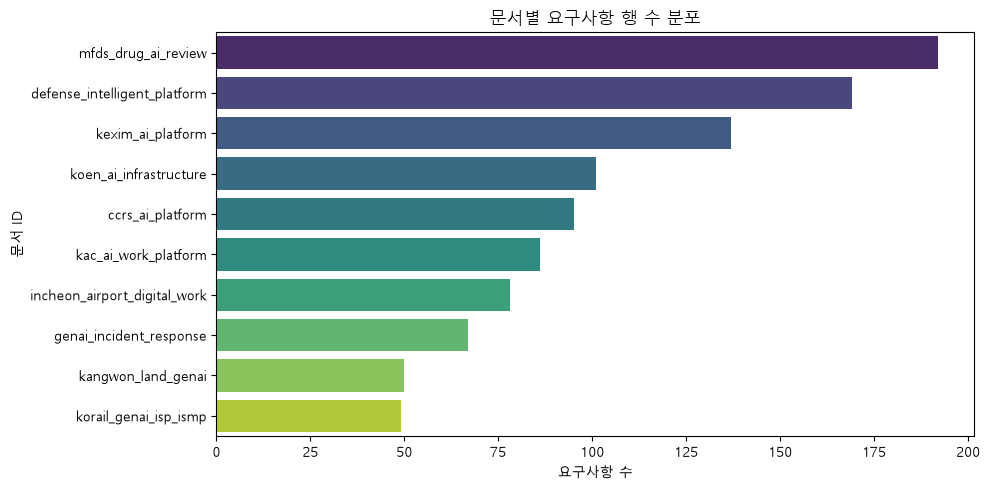

In [2]:
# 1. 문서별 요구사항 개수 집계
doc_counts = df['document_id'].value_counts().reset_index()
doc_counts.columns = ['document_id', 'count']
doc_counts['ratio_pct'] = (doc_counts['count'] / len(df) * 100).round(2)
display(doc_counts)

# 시각화
plt.figure(figsize=(10, 5))
sns.barplot(data=doc_counts, x='count', y='document_id', palette='viridis')
plt.title('문서별 요구사항 행 수 분포')
plt.xlabel('요구사항 수')
plt.ylabel('문서 ID')
plt.tight_layout()
plt.show()

,normalized_type,count,ratio_pct
0,기능 요구사항,245,23.93
1,프로젝트 관리·지원 요구사항,210,20.51
2,미지정 (None),101,9.86
3,데이터 요구사항,81,7.91
4,보안 요구사항,79,7.71
5,인프라·장비 요구사항,78,7.62
6,제약사항,54,5.27
7,품질 요구사항,52,5.08
8,인터페이스 요구사항,45,4.39
9,성능 요구사항,41,4.00


C:\Users\nodap\AppData\Local\Temp\ipykernel_472224\1996443750.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=norm_type_counts, x='count', y='normalized_type', palette='crest')


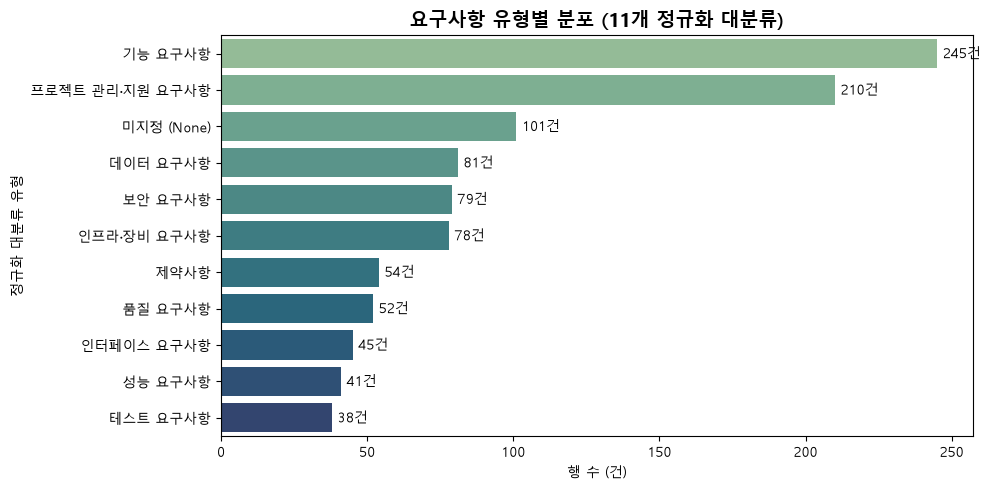

In [3]:
# 2. 정규화 요구사항 유형별 분포 (11개 통합 대분류)
norm_type_counts = df['normalized_type'].value_counts().reset_index()
norm_type_counts.columns = ['normalized_type', 'count']
norm_type_counts['ratio_pct'] = (norm_type_counts['count'] / len(df) * 100).round(2)
display(norm_type_counts)

# 시각화 (정규화 대분류)
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=norm_type_counts, x='count', y='normalized_type', palette='crest')
plt.title('요구사항 유형별 분포 (11개 정규화 대분류)', fontsize=14, fontweight='bold')
plt.xlabel('행 수 (건)')
plt.ylabel('정규화 대분류 유형')
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}건', (width + 2, p.get_y() + p.get_height() / 2.), va='center')
plt.tight_layout()
plt.show()


C:\Users\nodap\AppData\Local\Temp\ipykernel_472224\2789576975.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=raw_type_counts, x='count', y='raw_requirement_type', palette='magma')


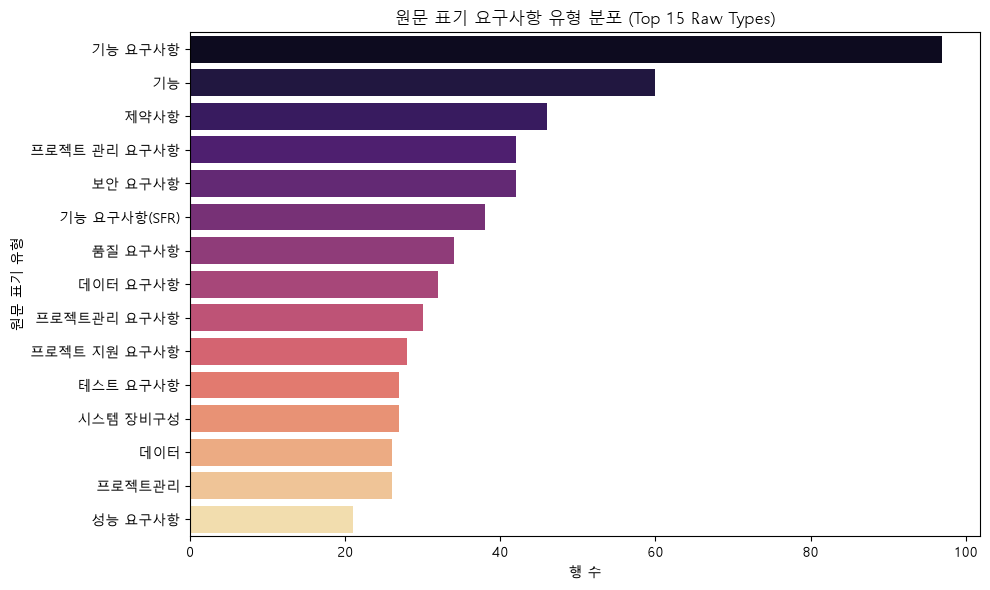

In [4]:
# 원문 표기 유형 Top 15 시각화 (세부 표기 차이 확인용)
raw_type_counts = df['requirement_type'].value_counts().head(15).reset_index()
raw_type_counts.columns = ['raw_requirement_type', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=raw_type_counts, x='count', y='raw_requirement_type', palette='magma')
plt.title('원문 표기 요구사항 유형 분포 (Top 15 Raw Types)')
plt.xlabel('행 수')
plt.ylabel('원문 표기 유형')
plt.tight_layout()
plt.show()

=== 문자 길이 통계 ===
count    1024.000000
mean      453.350586
std       423.011069
min        26.000000
50%       337.000000
90%       927.800000
95%      1213.600000
99%      2169.540000
max      4895.000000
Name: char_len, dtype: float64


C:\Users\nodap\AppData\Local\Temp\ipykernel_472224\1877099717.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='char_len', y='document_id', ax=axes[1], palette='coolwarm')


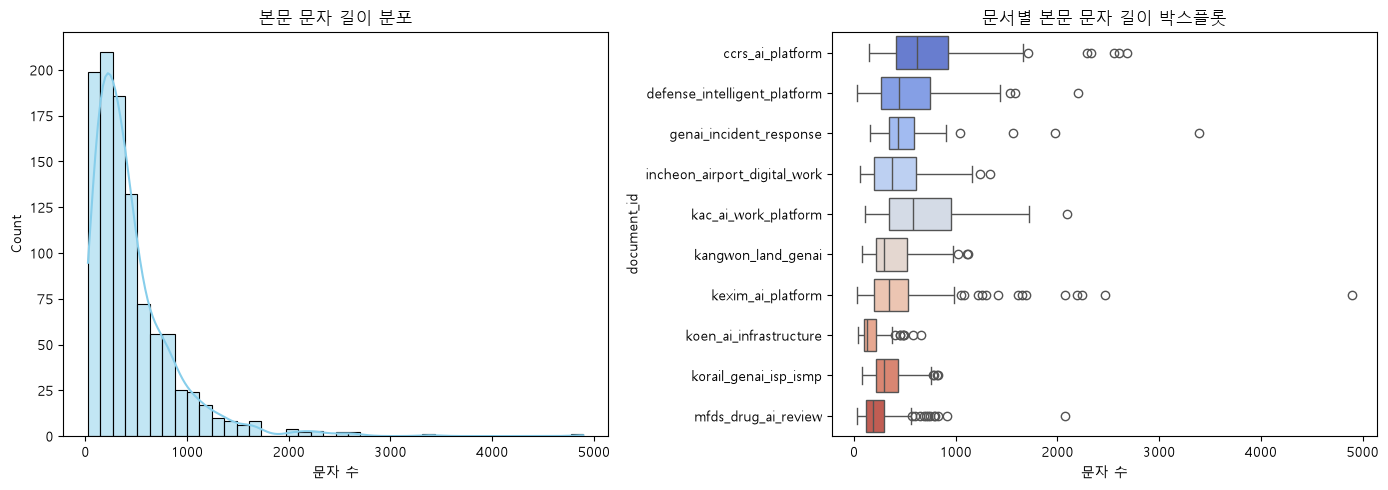

In [5]:
# 3. 본문 문자 길이 및 단어 수 파생 변수 생성
df['char_len'] = df['raw_requirement_text'].apply(len)
df['word_len'] = df['raw_requirement_text'].apply(lambda x: len(x.split()))

print("=== 문자 길이 통계 ===")
print(df['char_len'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

# 히스토그램 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['char_len'], bins=40, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('본문 문자 길이 분포')
axes[0].set_xlabel('문자 수')

sns.boxplot(data=df, x='char_len', y='document_id', ax=axes[1], palette='coolwarm')
axes[1].set_title('문서별 본문 문자 길이 박스플롯')
axes[1].set_xlabel('문자 수')

plt.tight_layout()
plt.show()

In [6]:
# 4. 승인된 원문 ID 예외(Policy Resolved) 및 중첩표(' | ') 검사
df['has_nested_table'] = df['raw_requirement_text'].apply(lambda x: ' | ' in x)
df['id_mismatch'] = df['requirement_id'] != df['source_requirement_id']

print(f"중첩표 포함 행 수: {df['has_nested_table'].sum()} 건")
print(f"승인된 원문 예외 ID (Canonical ID != Source ID) 행 수: {df['id_mismatch'].sum()} 건 (의도된 추적용 보존)")

if df['id_mismatch'].sum() > 0:
    display(df[df['id_mismatch']][['requirement_uid', 'requirement_id', 'source_requirement_id', 'requirement_name']])

중첩표 포함 행 수: 41 건
승인된 원문 예외 ID (Canonical ID != Source ID) 행 수: 1 건 (의도된 추적용 보존)


,requirement_uid,requirement_id,source_requirement_id,requirement_name
331,incheon_airport_digital_work:CUR-CM-001,CUR-CM-001,CUR-CM--001,공사 AI 업무 체계 고도화 컨설팅
